In [1]:
# fetch dataset from same folder
import pandas as pd

train = pd.read_csv(
    "train.csv",
    low_memory=False,
    dtype={"StateHoliday": str} # force pandas to read StateHoliday as string
)

store = pd.read_csv(
    "store.csv"
)

# merge dataset
df = train.merge(
    store,
    on="Store",
    how="left"
)

# check
print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.dtypes)

   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday StoreType Assortment  CompetitionDistance  \
0              1         c          a               1270.0   
1              1         a          a                570.0   
2              1         a          a              14130.0   
3              1         c          c                620.0   
4              1         a          a              29910.0   

   CompetitionOpenSinceMonth  CompetitionOpenSinceYear  Promo2  \
0                        9.0                    2008.0       0   
1                   

In [2]:
# data cleaning
# replace missing values (int and float) with median
num_cols = [
    "CompetitionDistance",
    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear",
    "Promo2SinceWeek",
    "Promo2SinceYear"
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# replace PromoInterval (str) with None
df["PromoInterval"] = df["PromoInterval"].fillna("None")

# remove when stores are closed
df = df[df["Open"] == 1]

# remove 0 sales
df = df[df["Sales"] > 0]

# convert date
df["Date"] = pd.to_datetime(df["Date"])

# sort chronologically
df = df.sort_values(["Store", "Date"])

# verify
print(df.duplicated().sum())
print(df.isnull().sum())

0
Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64


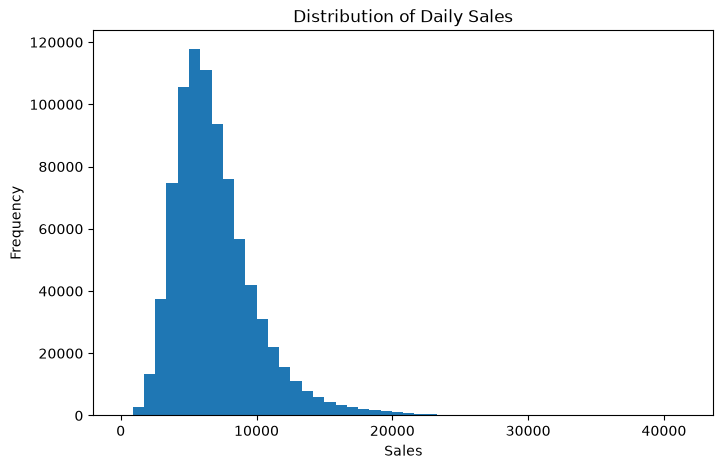

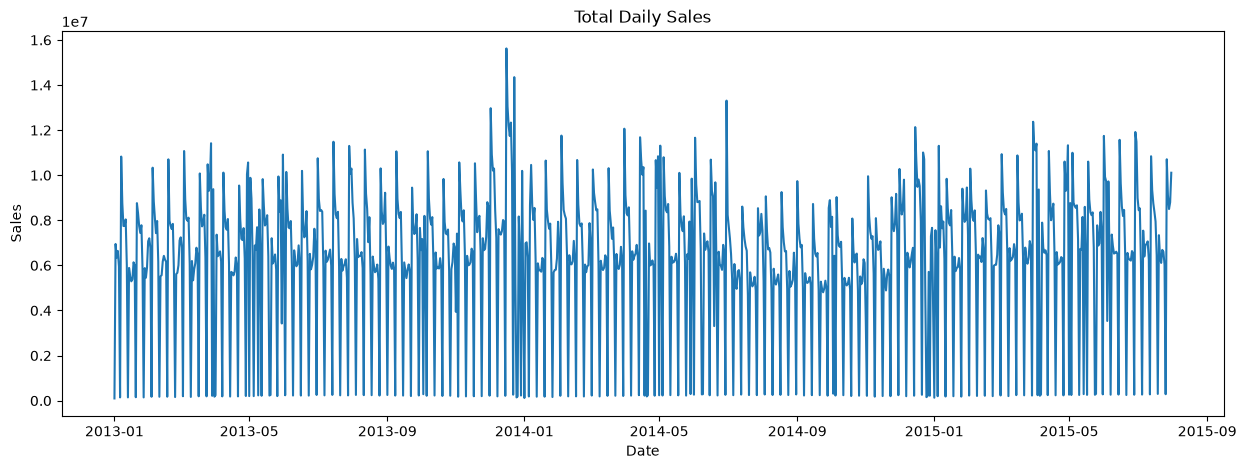

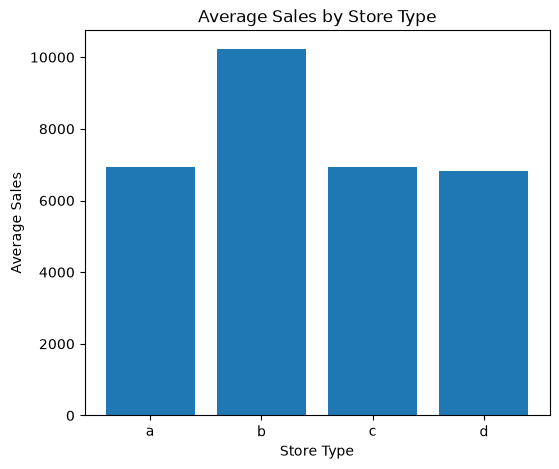

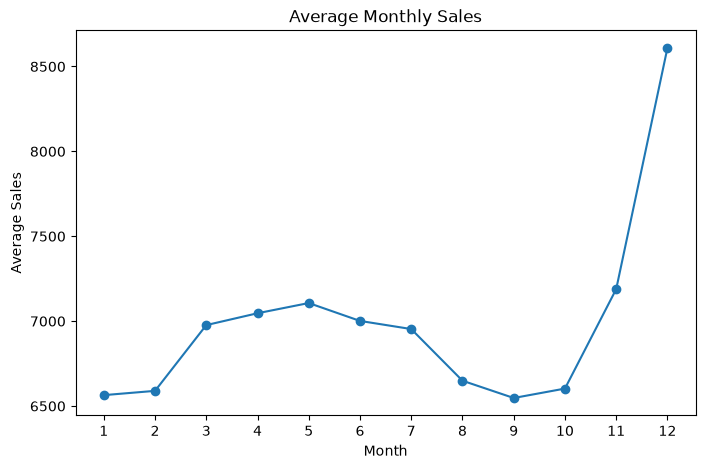

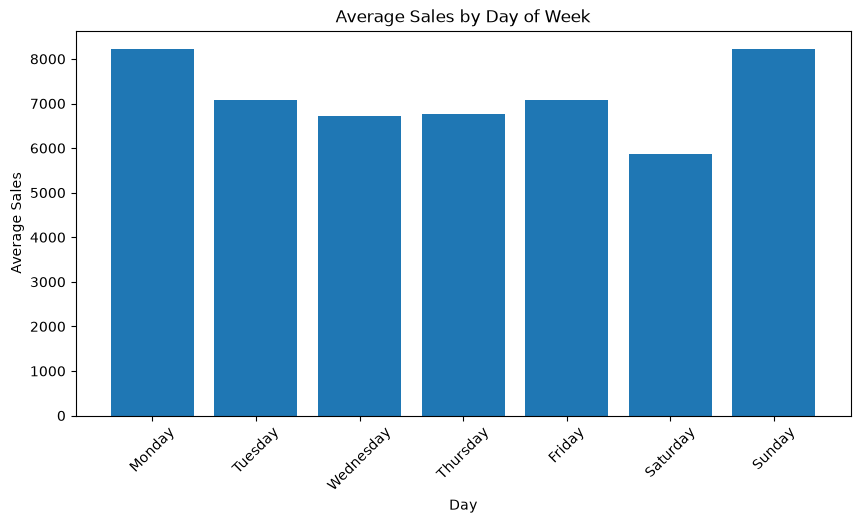

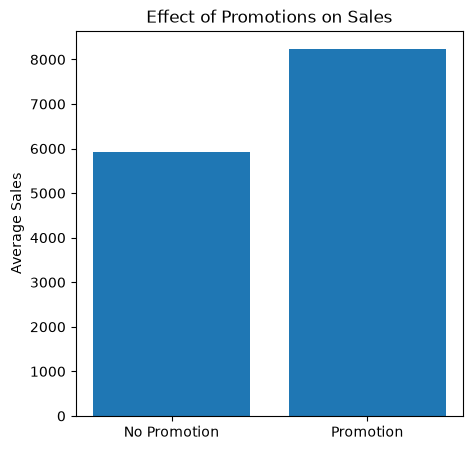

In [3]:
# visualise data
import matplotlib.pyplot as plt

# sales distribution
plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=50)
plt.title("Distribution of Daily Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# daily sales over time
daily_sales = (
    df.groupby("Date")["Sales"]
      .sum()
)
plt.figure(figsize=(15,5))
plt.plot(
    daily_sales.index,
    daily_sales.values
)
plt.title("Total Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# sales by store type
sales_storetype = (
    df.groupby("StoreType")["Sales"]
      .mean()
)
plt.figure(figsize=(6,5))
plt.bar(
    sales_storetype.index,
    sales_storetype.values
)
plt.title("Average Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Sales")
plt.show()

# sales by month
df["Month"] = df["Date"].dt.month
monthly_sales = (
    df.groupby("Month")["Sales"]
      .mean()
)
plt.figure(figsize=(8,5))
plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)
plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(range(1,13))
plt.show()

# sales by day of week
df["DayOfWeekName"] = (
    df["Date"]
    .dt.day_name()
)
days = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
sales_day = (
    df.groupby("DayOfWeekName")["Sales"]
      .mean()
      .reindex(days)
)
plt.figure(figsize=(10,5))
plt.bar(
    sales_day.index,
    sales_day.values
)
plt.title("Average Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.show()

# sales affected by promotion
promo_sales = (
    df.groupby("Promo")["Sales"]
      .mean()
)
plt.figure(figsize=(5,5))
plt.bar(
    ["No Promotion", "Promotion"],
    promo_sales.values
)
plt.title("Effect of Promotions on Sales")
plt.ylabel("Average Sales")
plt.show()

In [4]:
# features
# date
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Quarter"] = df["Date"].dt.quarter

# lag (sales history)
df["lag1"] = (df.groupby("Store")["Sales"].shift(1)) # 1 day ago
df["lag7"] = (df.groupby("Store")["Sales"].shift(7)) # 7 days ago
df["lag14"] = (df.groupby("Store")["Sales"].shift(14)) # 14 days ago
df["lag30"] = (df.groupby("Store")["Sales"].shift(30)) # 30 days ago

# rolling (average sales)
df["rolling7"] = (
    df.groupby("Store")["Sales"]
        .transform(lambda x: x.rolling(7).mean()) # 7 days
)
df["rolling14"] = (
    df.groupby("Store")["Sales"]
        .transform(lambda x: x.rolling(14).mean()) # 14 days
)
df["rolling30"] = (
    df.groupby("Store")["Sales"]
        .transform(lambda x: x.rolling(30).mean()) # 30 days
)

df["rolling7_std"] = (
    df.groupby("Store")["Sales"]
      .transform(lambda x: x.rolling(7).std()) # sales variability in 7 days
)

df["rolling30_std"] = (
    df.groupby("Store")["Sales"]
      .transform(lambda x: x.rolling(30).std()) # sales variability in 30 days
)

# competition (how long competitors have been open)
df["CompetitionOpenYears"] = (df["Year"] - df["CompetitionOpenSinceYear"])

# remove missing values from lag and rolling
df = df.dropna()

In [5]:
# prepare features and target
features = [
    "Customers",
    "Promo",
    "Promo2",
    "SchoolHoliday",
    "CompetitionDistance",
    "lag1",
    "lag7",
    "lag14",
    "lag30",
    "rolling7",
    "rolling14",
    "rolling30",
    "Month",
    "Week",
    "DayOfWeek",
]

import numpy as np

df["Sales"] = np.log1p(df["Sales"])

In [6]:
X = df[features]
y = df["Sales"]

from sklearn.preprocessing import MinMaxScaler

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_scaled = x_scaler.fit_transform(X)

y_scaled = y_scaler.fit_transform(
    y.values.reshape(-1, 1)
)

train_size = int(len(X_scaled) * 0.70)
val_size = int(len(X_scaled) * 0.15)

X_train = X_scaled[:train_size]
y_train = y_scaled[:train_size]

X_val = X_scaled[
    train_size:train_size + val_size
]

y_val = y_scaled[
    train_size:train_size + val_size
]

X_test = X_scaled[
    train_size + val_size:
]

y_test = y_scaled[
    train_size + val_size:
]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (567621, 15)
Validation: (121633, 15)
Test: (121634, 15)


In [7]:
import numpy as np

X_train_val = np.vstack((X_train, X_val))
y_train_val = np.vstack((y_train, y_val))

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(Dense(64, activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation="relu"))
model.add(Dense(16, activation="relu"))
model.add(Dense(1))
optimizer = Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss="mse"
)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

C:\Users\Charlotte\miniconda3\envs\newenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
17739/17739 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step - loss: 6.9736e-04 - val_loss: 3.6374e-04
Epoch 2/200
17739/17739 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - loss: 3.1242e-04 - val_loss: 3.2784e-04
Epoch 3/200
17739/17739 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step - loss: 2.8538e-04 - val_loss: 3.1357e-04
Epoch 4/200
17739/17739 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step - loss: 2.7109e-04 - val_loss: 2.8521e-04
Epoch 5/200
17739/17739 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step - loss: 2.6157e-04 - val_loss: 2.8234e-04
Epoch 6/200
17739/17739 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 2.5448e-04 - val_loss: 3.0196e-04
Epoch 7/200
17739/17739 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - loss: 2.4954e-04 - val_loss: 3.0148e-04
Epoch 8/200
17739/17739 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 2.4477e-04 - val_loss: 2.9410e-04
Epoch 9/200
17739/17739 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 2.4102e-04 - val_loss: 2.9175e-04
Epoch 10/200
17739/17739 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 2.3725e-04 - val_loss: 2.8283e-04

In [42]:
pred_scaled = model.predict(X_test)

pred_log = y_scaler.inverse_transform(pred_scaled)
actual_log = y_scaler.inverse_transform(y_test)

pred = np.expm1(pred_log)
actual = np.expm1(actual_log)

3802/3802 ━━━━━━━━━━━━━━━━━━━━ 4s 944us/step


MSE : 540756.8550022742
RMSE: 735.3617171176877
MAPE: 7.853293733570517


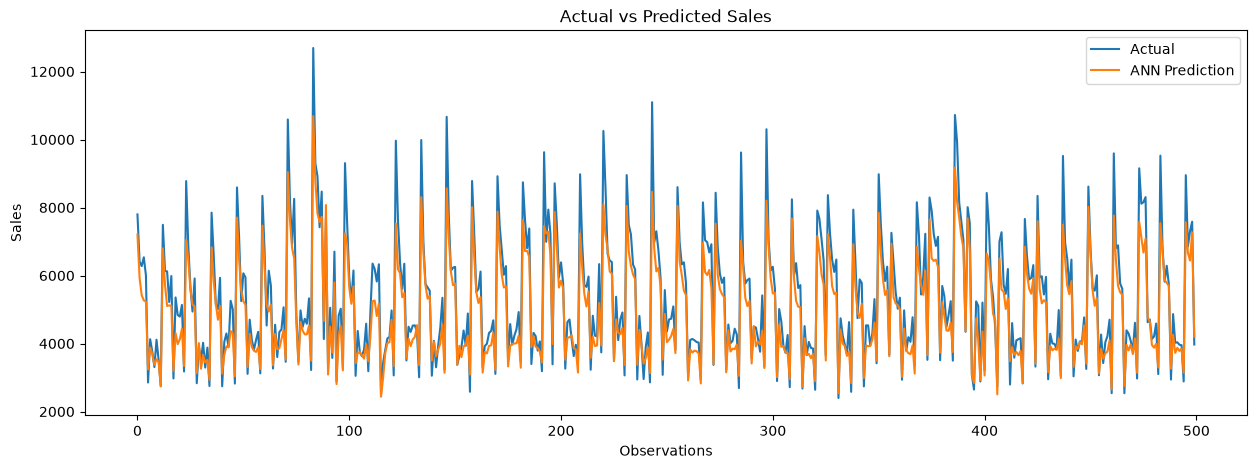

In [43]:
# evaluate
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(actual, pred)

rmse = np.sqrt(mse)

mape = np.mean(
    np.abs((actual - pred) / actual)
) * 100

print("MSE :", mse)
print("RMSE:", rmse)
print("MAPE:", mape)

plt.figure(figsize=(15,5))

plt.plot(
    actual[:500],
    label="Actual"
)

plt.plot(
    pred[:500],
    label="ANN Prediction"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Observations")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [24]:
# move to GA
# initialise population
import random

POP_SIZE = 20
GENERATIONS = 20

NEURONS1 = [32, 64, 128]

NEURONS2 = [16, 32, 64]

LEARNING_RATE = [
    0.0005,
    0.001,
    0.005
]

BATCH_SIZE = [
    16,
    32,
    64
]

DROPOUT = [
    0.0,
    0.1,
    0.2,
    0.3
]

# population: neurons1, neurons2, learning_rate, batch_size, dropout
def create_population():
    population = []
    for _ in range(POP_SIZE):
        chromosome = [
            random.choice(NEURONS1),
            random.choice(NEURONS2),
            random.choice(LEARNING_RATE),
            random.choice(BATCH_SIZE),
            random.choice(DROPOUT)
        ]
        population.append(chromosome)

    return population

In [25]:
# build ANN from chromosome
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_model(chromosome):

    n1, n2, lr, batch, drop = chromosome

    model = Sequential([

        Input(shape=(X_train.shape[1],)),

        Dense(
            n1,
            activation="relu"
        ),

        Dropout(drop),

        Dense(
            n2,
            activation="relu"
        ),

        Dropout(drop),

        Dense(1)

    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="mse"
    )

    return model

In [31]:
# fitness function
from sklearn.metrics import mean_absolute_percentage_error
from tensorflow.keras.callbacks import EarlyStopping

# Use only a subset for GA to speed up optimization
X_train_ga = X_train[:100000]
y_train_ga = y_train[:100000]

X_val_ga = X_val[:20000]
y_val_ga = y_val[:20000]

def evaluate(chromosome):

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
    
    n1, n2, lr, batch_size, drop = chromosome

    model = build_model(chromosome)

    model.fit(
        X_train_ga,
        y_train_ga,
        validation_data=(X_val_ga, y_val_ga),
        epochs=10,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    pred = model.predict(
        X_val_ga,
        verbose=0
    )

    pred = y_scaler.inverse_transform(pred)
    actual = y_scaler.inverse_transform(y_val_ga)

    mape = mean_absolute_percentage_error(
        actual,
        pred
    ) * 100

    fitness = 1 / (mape + 1e-6)

    return fitness

In [32]:
# roulette wheel selection
def roulette_selection(
    population,
    fitness_values
):

    total_fitness = sum(fitness_values)

    probs = [
        fit / total_fitness
        for fit in fitness_values
    ]

    selected = []

    for _ in range(POP_SIZE):

        r = random.random()

        cumulative = 0

        for i in range(len(population)):

            cumulative += probs[i]

            if r <= cumulative:

                selected.append(
                    population[i]
                )

                break

    return selected

In [33]:
# crossover
def crossover(parent1, parent2):

    child1 = []
    child2 = []

    for g1, g2 in zip(parent1, parent2):

        if random.random() < 0.5:

            child1.append(g1)
            child2.append(g2)

        else:

            child1.append(g2)
            child2.append(g1)

    return child1, child2

In [34]:
# mutation
PM = 0.10

def mutate(chromosome):

    if random.random() < PM:
        chromosome[0] = random.choice(NEURONS1)

    if random.random() < PM:
        chromosome[1] = random.choice(NEURONS2)

    if random.random() < PM:
        chromosome[2] = random.choice(LEARNING_RATE)

    if random.random() < PM:
        chromosome[3] = random.choice(BATCH_SIZE)

    if random.random() < PM:
        chromosome[4] = random.choice(DROPOUT)

    return chromosome

In [35]:
# main GA loop
# initialize population
population = create_population()

best_individual = None
best_fitness = -float("inf")

for generation in range(GENERATIONS):

    print(f"\nGeneration {generation+1}")

    # evaluate every chromosome
    fitness_values = []

    for chromosome in population:

        fitness = evaluate(chromosome)

        fitness_values.append(fitness)

    # find best chromosome in this generation
    generation_best = max(fitness_values)
    generation_best_index = fitness_values.index(generation_best)
    print("Best Fitness:", generation_best)
    print("Best Individual:", population[generation_best_index])

    # update global best
    if generation_best > best_fitness:

        best_fitness = generation_best

        best_individual = (
            population[generation_best_index].copy()
        )

    # selection
    selected = roulette_selection(
        population,
        fitness_values
    )

    # next generation
    new_population = []

    for i in range(0, POP_SIZE, 2):

        parent1 = selected[i]
        parent2 = selected[i + 1]

        child1, child2 = crossover(
            parent1,
            parent2
        )

        child1 = mutate(child1)
        child2 = mutate(child2)

        new_population.append(child1)
        new_population.append(child2)

    # elitism
    new_population[0] = best_individual.copy()

    population = new_population

print("Best Chromosome:")
print(best_individual)
print("Best Fitness:")
print(best_fitness)


Generation 1
Best Fitness: 0.9046960689843562
Best Individual: [128, 16, 0.001, 16, 0.0]

Generation 2
Best Fitness: 0.906772261216821
Best Individual: [128, 16, 0.001, 16, 0.0]

Generation 3
Best Fitness: 0.9137442958500016
Best Individual: [128, 16, 0.001, 32, 0.1]

Generation 4
Best Fitness: 0.8910356779853742
Best Individual: [128, 16, 0.001, 32, 0.1]

Generation 5
Best Fitness: 0.8491585683084893
Best Individual: [128, 64, 0.001, 32, 0.1]

Generation 6
Best Fitness: 0.88004155538648
Best Individual: [128, 64, 0.001, 32, 0.1]

Generation 7
Best Fitness: 0.880359953609712
Best Individual: [32, 16, 0.005, 16, 0.0]

Generation 8
Best Fitness: 0.8816937039322186
Best Individual: [128, 16, 0.001, 32, 0.2]

Generation 9
Best Fitness: 0.9127639883882176
Best Individual: [32, 32, 0.001, 16, 0.0]

Generation 10
Best Fitness: 0.8799477757766608
Best Individual: [32, 64, 0.001, 32, 0.0]

Generation 11
Best Fitness: 0.8699265291493685
Best Individual: [128, 16, 0.001, 32, 0.1]

Generation 12


In [36]:
# build final model
import numpy as np

X_train_final = np.vstack((X_train, X_val))
y_train_final = np.vstack((y_train, y_val))

final_model = build_model(best_individual)

In [37]:
# train final model
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

batch_size = best_individual[3]

history = final_model.fit(
    X_train_final,
    y_train_final,
    validation_split=0.1,
    epochs=100,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
19386/19386 ━━━━━━━━━━━━━━━━━━━━ 34s 2ms/step - loss: 0.0018 - val_loss: 3.5921e-04
Epoch 2/100
19386/19386 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - loss: 4.0192e-04 - val_loss: 3.2721e-04
Epoch 3/100
19386/19386 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step - loss: 3.8797e-04 - val_loss: 3.3494e-04
Epoch 4/100
19386/19386 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step - loss: 3.7875e-04 - val_loss: 3.4985e-04
Epoch 5/100
19386/19386 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 3.7235e-04 - val_loss: 3.1875e-04
Epoch 6/100
19386/19386 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step - loss: 3.6971e-04 - val_loss: 3.3654e-04
Epoch 7/100
19386/19386 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step - loss: 3.6374e-04 - val_loss: 3.2094e-04
Epoch 8/100
19386/19386 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step - loss: 3.6046e-04 - val_loss: 3.5887e-04
Epoch 9/100
19386/19386 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step - loss: 3.5775e-04 - val_loss: 3.1205e-04
Epoch 10/100
19386/19386 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 3.5593e-04 - val_loss: 3.1034e-04
Epo

3802/3802 ━━━━━━━━━━━━━━━━━━━━ 3s 855us/step
3802/3802 ━━━━━━━━━━━━━━━━━━━━ 3s 840us/step
MSE : 626276.7840367066
RMSE: 791.3765121841225
MAPE: 8.398413020411933


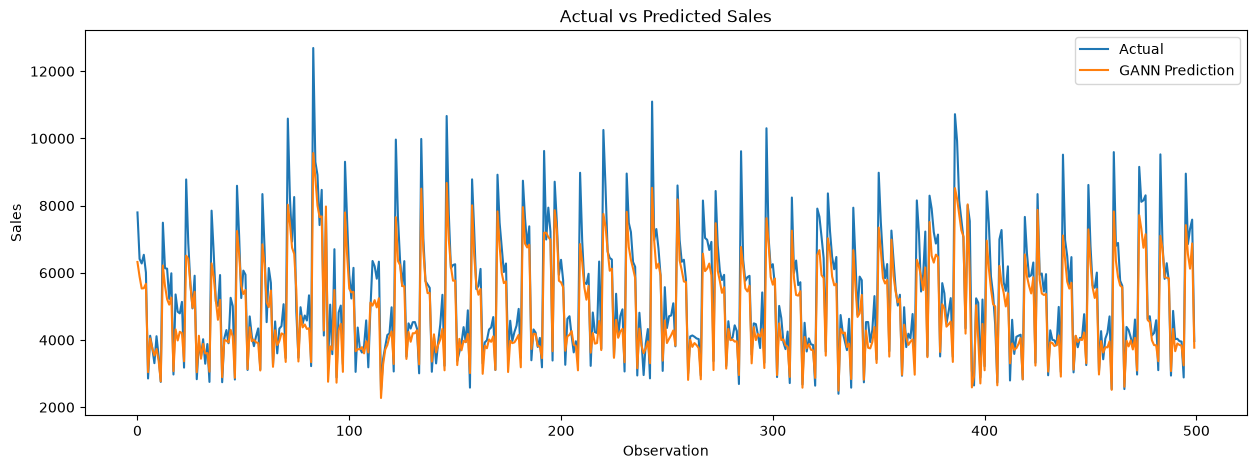

In [38]:
# predict test set
pred_scaled = final_model.predict(X_test)

# convert back to sales unit
# calculate metrics
from sklearn.metrics import mean_squared_error
import numpy as np

pred_scaled = final_model.predict(X_test)

pred = y_scaler.inverse_transform(pred_scaled)
actual = y_scaler.inverse_transform(y_test)

pred = np.expm1(pred)
actual = np.expm1(actual)

mse = mean_squared_error(actual, pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((actual - pred) / actual)) * 100

print("MSE :", mse)
print("RMSE:", rmse)
print("MAPE:", mape)

# plot predictions
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(actual[:500], label="Actual")
plt.plot(pred[:500], label="GANN Prediction")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Observation")
plt.ylabel("Sales")
plt.legend()

plt.show()